In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pa_gs = pd.read_csv('data/pa_data.csv')
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Lakeside': lakeside_pa_stations, 'Inland': inland_pa_stations,
           'Eastern': east_pa_stations, 'Western': west_pa_stations, 'Northern': north_pa_stations, 'Southern': south_pa_stations,
           'Low Elevation': low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

# find the 1st and 3rd quartiles of each year of data for GSL and DTR
# subtract the 1st quartile value from the 3rd quartile value for the IQR
# plot yearly IQRs against time
# determine whether there's a statistically significant change in the IQR values

pa_gs = pa_gs[pa_gs['year'] >= 1960]

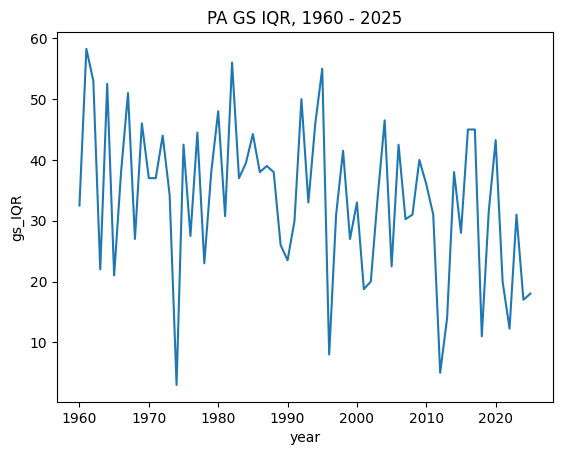

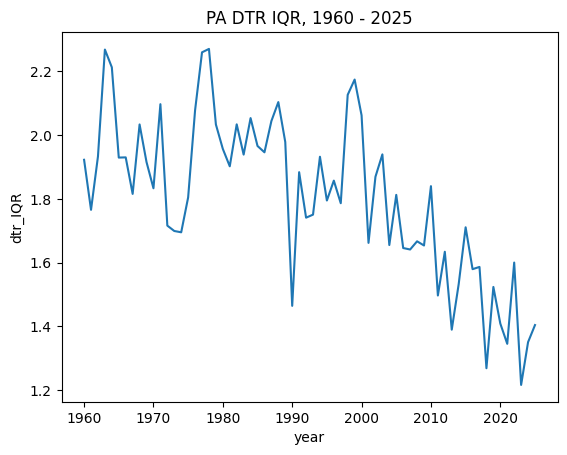

In [50]:
pa_gs_cleaned = remove_nulls_simple(pa_gs, ['year', 'station_name', 'growing_season_length', 'dtr_annual'])
pa_gs_dtr = pa_gs_cleaned.groupby('year').agg({'growing_season_length': ['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
                                              'dtr_annual': ['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]})
pa_gs_dtr.columns = ['gsl_mean', 'gsl_q1', 'gsl_q3', 'dtr_mean', 'dtr_q1', 'dtr_q3']
pa_gs_dtr = pa_gs_dtr.reset_index()
gs_IQR = pa_gs_dtr['gsl_q3'] - pa_gs_dtr['gsl_q1']
dtr_IQR = pa_gs_dtr['dtr_q3'] - pa_gs_dtr['dtr_q1']
gs_IQR = gs_IQR.to_frame()
dtr_IQR = dtr_IQR.to_frame()
pa_gs_dtr = pd.concat([pa_gs_dtr, gs_IQR, dtr_IQR], axis=1)
pa_gs_dtr.columns = ['year', 'gsl_mean', 'gsl_q1', 'gsl_q3', 'dtr_mean', 'dtr_q1', 'dtr_q3', 'gs_IQR', 'dtr_IQR']

fig = sns.lineplot(data = pa_gs_dtr, x ='year', y = 'gs_IQR')
plt.title('PA GS IQR, 1960 - 2025')
plt.show()

fig = sns.lineplot(data = pa_gs_dtr, x ='year', y = 'dtr_IQR')
plt.title('PA DTR IQR, 1960 - 2025')
plt.show()